<a href="https://colab.research.google.com/github/pratikmojumder/IDW_Map/blob/main/IDW_heat_and_cold_wave.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Boundary loaded successfully. Clipping grid to study area.
Masking values outside the boundary. This might take a few seconds...


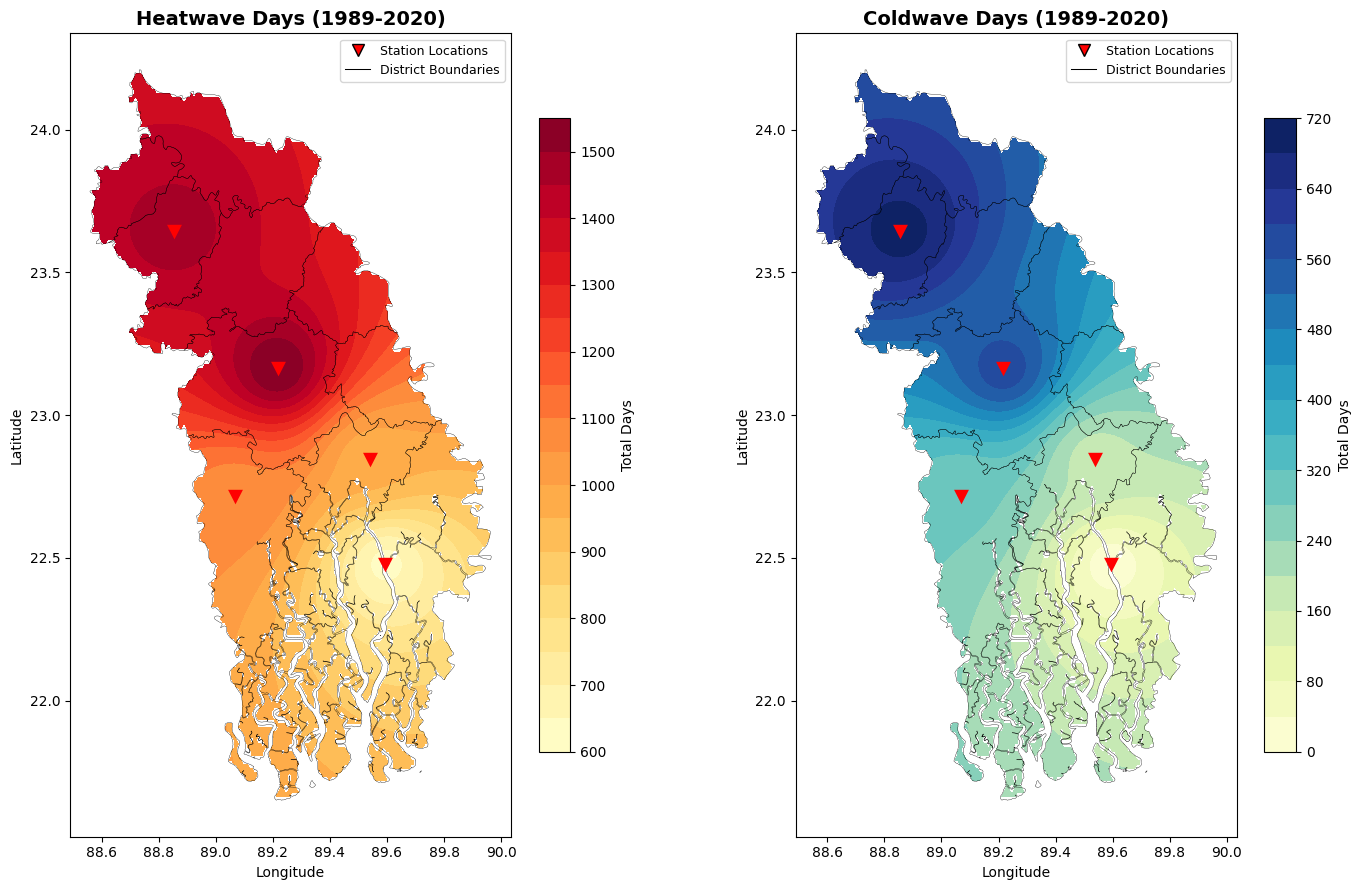

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from google.colab import drive
drive.mount('/content/drive')

# Import Line2D for legend proxy
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm # Added for font management

def generate_idw(lons, lats, values, grid_lon, grid_lat, power=2):
    """
    Calculates the Inverse Distance Weighting (IDW) interpolation.
    """
    glon_flat = grid_lon.flatten()
    glat_flat = grid_lat.flatten()

    # Calculate distance matrix (grid points vs station points)
    dists = np.sqrt((glon_flat[:, np.newaxis] - lons)**2 + (glat_flat[:, np.newaxis] - lats)**2)

    # Prevent division by zero if a grid point perfectly matches a station
    dists = np.where(dists == 0, 1e-10, dists)

    # Apply IDW formula
    weights = 1.0 / (dists ** power)
    weighted_values = np.sum(weights * values, axis=1) / np.sum(weights, axis=1)

    return weighted_values.reshape(grid_lon.shape)

# 1. Prepare the Station Data
stations = ['Chuadanga', 'Jessore', 'Khulna', 'Mongla', 'Satkhira']

# Approximate coordinates for the stations
lons = np.array([88.8556, 89.2182, 89.5403, 89.5960, 89.0706])
lats = np.array([23.6439, 23.1634, 22.8456, 22.4795, 22.7153])

# Aggregated totals from 1989 to 2020 (treating blanks as 0)
coldwave_days = np.array([694, 583, 180, 20, 285])
heatwave_days = np.array([1472, 1549, 968, 633, 1070])

# 2. Load Boundary and Setup Spatial Grid
# Replace this with the path to your actual shapefile (e.g., 'khulna_division.shp')
boundary_path='/content/drive/MyDrive/Colab_Notebooks/khulna_division.shx'

try:
    boundary_gdf = gpd.read_file(boundary_path)
    # Get the bounding box of the shapefile
    minx, miny, maxx, maxy = boundary_gdf.total_bounds
    # Use union_all() instead of unary_union to avoid DeprecationWarning
    study_polygon = boundary_gdf.geometry.union_all()
    print("Boundary loaded successfully. Clipping grid to study area.")

    # Apply 5% padding to the bounding box to "zoom out"
    padding_percentage = 0.05
    bbox_width = maxx - minx
    bbox_height = maxy - miny
    minx -= bbox_width * padding_percentage
    maxx += bbox_width * padding_percentage
    miny -= bbox_height * padding_percentage
    maxy += bbox_height * padding_percentage

except Exception as e:
    print(f"Could not load boundary file ({e}). Falling back to point bounding box.")
    # Fallback padding if no shapefile is found
    pad = 5.0
    minx, maxx = lons.min() - pad, lons.max() + pad
    miny, maxy = lats.min() - pad, lats.max() + pad
    study_polygon = None

# Create the coordinate grid
grid_lon, grid_lat = np.meshgrid(
    np.linspace(minx, maxx, 200),
    np.linspace(miny, maxy, 200)
)

# 3. Calculate IDW Interpolations
idw_heat = generate_idw(lons, lats, heatwave_days, grid_lon, grid_lat, power=2)
idw_cold = generate_idw(lons, lats, coldwave_days, grid_lon, grid_lat, power=2)

# Apply the spatial mask if a boundary was loaded
if study_polygon is not None:
    # Check if each point in the grid is inside the polygon
    print("Masking values outside the boundary. This might take a few seconds...")
    mask = np.array([
        study_polygon.contains(Point(x, y))
        for x, y in zip(grid_lon.flatten(), grid_lat.flatten())
    ]).reshape(grid_lon.shape)

    # Set values outside the boundary to NaN so they won't plot
    idw_heat = np.where(mask, idw_heat, np.nan)
    idw_cold = np.where(mask, idw_cold, np.nan)

# Define districts for specific labeling
special_districts = ['Jhenaidah', 'Magura', 'Kushtia', 'Jessore', 'Chuadanga', 'Meherpur', 'Narail']

# Before plotting, configure matplotlib to use an emoji font if available
# This helps with displaying unicode characters like the pin emoji
found_emoji_font = False
for font in fm.fontManager.ttflist:
    if 'Noto Color Emoji' in font.name:
        plt.rcParams['font.sans-serif'] = ['Noto Color Emoji', 'DejaVu Sans', 'sans-serif'] # Prioritize Noto, then fallback
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break
    elif 'Segoe UI Emoji' in font.name: # For Windows environments
        plt.rcParams['font.sans-serif'] = ['Segoe UI Emoji', 'DejaVu Sans', 'sans-serif']
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break

if not found_emoji_font:
    plt.rcParams['font.family'] = 'sans-serif'
    print("Warning: No specific emoji font found. Pin emoji might not display correctly.")

# 4. Plot the Maps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 9)) # Increased figure size for better readability

# --- Heatwave Map ---
contour1 = ax1.contourf(grid_lon, grid_lat, idw_heat, levels=20, cmap='YlOrRd')

# Add station pins using text (unicode character for pin) with red color
for lon, lat in zip(lons, lats):
    ax1.text(lon, lat, '\u25BC', fontsize=14, ha='center', va='center', zorder=8, color='red')

# Plot boundary outline and add district labels if available
if study_polygon is not None:
    boundary_gdf.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=0.25, zorder=6) # Increased linewidth slightly
    # # Add district labels
    # for idx, row in boundary_gdf.iterrows():
ax1.set_title('Heatwave Days (1989-2020)', fontsize=14, weight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude', rotation='vertical')
fig.colorbar(contour1, ax=ax1, label='Total Days', fraction=0.046, pad=0.04)

# Set aspect ratio for accurate scale bar
ax1.set_aspect('equal', adjustable='box')

# Calculate dx for ScaleBar
mean_lat = (miny + maxy) / 2
meters_per_deg_lat = 110574 # Approx. meters per degree latitude
scalebar_dx = 1000 / meters_per_deg_lat # Adjusted for kilometers


# Add Legend for ax1
# Changed marker to 'v' (downward triangle) and included unicode character in label text
station_proxy = Line2D([0], [0], marker='v', markersize=8, markeredgecolor='black', linestyle='None', label='Station Locations', color='red')
district_boundary_proxy = Line2D([0], [0], linestyle='-', color='black', linewidth=0.75, label='District Boundaries')
ax1.legend(handles=[station_proxy, district_boundary_proxy], loc='upper right', frameon=True, fontsize=9)


# --- Coldwave Map ---
contour2 = ax2.contourf(grid_lon, grid_lat, idw_cold, levels=20, cmap='YlGnBu')

# Add station pins using text (unicode character for pin) with red color
for lon, lat in zip(lons, lats):
    ax2.text(lon, lat, '\u25BC', fontsize=14, ha='center', va='center', zorder=8, color='red')

# Plot boundary outline and add district labels if available
if study_polygon is not None:
    boundary_gdf.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=0.25, zorder=6) # Increased linewidth slightly
    # # Add district labels
    #

ax2.set_title('Coldwave Days (1989-2020)', fontsize=14, weight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude', rotation='vertical')
fig.colorbar(contour2, ax=ax2, label='Total Days', fraction=0.046, pad=0.04)

# Set aspect ratio for accurate scale bar
ax2.set_aspect('equal', adjustable='box')


# Add Legend for ax2
# Re-use the same proxy artists
ax2.legend(handles=[station_proxy, district_boundary_proxy], loc='upper right', frameon=True, fontsize=9)


# Clean up layout and display/save
plt.tight_layout()
plt.savefig('idw_maps_masked.png', dpi=300, bbox_inches='tight')
plt.show()
# Download trigger for Google Colab
try:
    from google.colab import files
    files.download('idw_maps_masked.png')
except ImportError:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Boundary loaded successfully. Clipping grid to study area.
Masking values outside the boundary. This might take a few seconds...


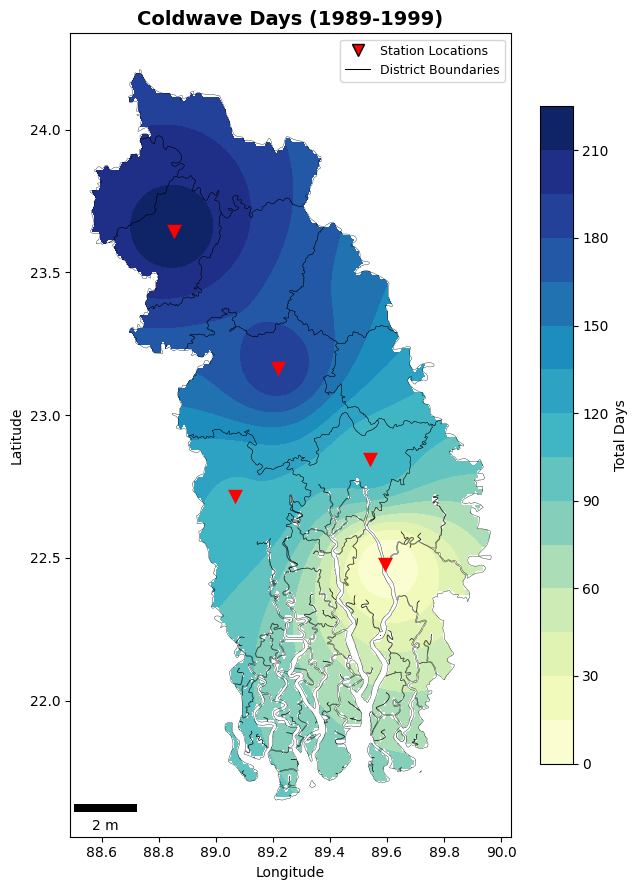

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from google.colab import drive
drive.mount('/content/drive')

# Import Line2D for legend proxy
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm # Added for font management
from matplotlib_scalebar.scalebar import ScaleBar # Import ScaleBar
import pandas as pd # Import pandas for data handling
from io import StringIO # Import StringIO for reading string data

def generate_idw(lons, lats, values, grid_lon, grid_lat, power=2):
    """
    Calculates the Inverse Distance Weighting (IDW) interpolation.
    """
    glon_flat = grid_lon.flatten()
    glat_flat = grid_lat.flatten()

    # Calculate distance matrix (grid points vs station points)
    dists = np.sqrt((glon_flat[:, np.newaxis] - lons)**2 + (glat_flat[:, np.newaxis] - lats)**2)

    # Prevent division by zero if a grid point perfectly matches a station
    dists = np.where(dists == 0, 1e-10, dists)

    # Apply IDW formula
    weights = 1.0 / (dists ** power)
    weighted_values = np.sum(weights * values, axis=1) / np.sum(weights, axis=1)

    return weighted_values.reshape(grid_lon.shape)

# Function to add North Arrow
def add_north_arrow(ax, xy_pos=(0.08, 0.92), size=0.06, text_color='black', arrow_color='black'):
    x, y = xy_pos
    ax.annotate('N', xy=(x, y), xytext=(0, size), textcoords=ax.transAxes, arrowprops=dict(facecolor=arrow_color, edgecolor=arrow_color, shrink=0.05),
                ha='center', va='bottom', fontsize=12, color=text_color, weight='bold', zorder=7)

# 1. Prepare the Station Data
stations = ['Chuadanga', 'Jessore', 'Khulna', 'Mongla', 'Satkhira']

# Approximate coordinates for the stations
lons = np.array([88.8556, 89.2182, 89.5403, 89.5960, 89.0706])
lats = np.array([23.6439, 23.1634, 22.8456, 22.4795, 22.7153])

# Climate Data specifically for Coldwave Days (1989-1999)
# This data is extracted from the user's request. Mongla has no value so it will be 0.
coldwave_data_str = """Station Name\tColdwave Days (1989-1999)
Chuadanga\t217
Jessore\t190
Khulna\t115
Mongla\t
Satkhira\t119"""
df_coldwave = pd.read_csv(StringIO(coldwave_data_str), sep='\t')
df_coldwave = df_coldwave.fillna(0)
coldwave_89_99 = df_coldwave['Coldwave Days (1989-1999)'].values

# Use the specific data for the plot
coldwave_days = coldwave_89_99 # Assign the specific coldwave data here

# 2. Load Boundary and Setup Spatial Grid
# Replace this with the path to your actual shapefile (e.g., 'khulna_division.shp')
boundary_path='/content/drive/MyDrive/Colab_Notebooks/khulna_division.shx'

try:
    boundary_gdf = gpd.read_file(boundary_path)
    # Get the bounding box of the shapefile
    minx, miny, maxx, maxy = boundary_gdf.total_bounds
    # Use union_all() instead of unary_union to avoid DeprecationWarning
    study_polygon = boundary_gdf.geometry.union_all()
    print("Boundary loaded successfully. Clipping grid to study area.")

    # Apply 5% padding to the bounding box to "zoom out"
    padding_percentage = 0.05
    bbox_width = maxx - minx
    bbox_height = maxy - miny
    minx -= bbox_width * padding_percentage
    maxx += bbox_width * padding_percentage
    miny -= bbox_height * padding_percentage
    maxy += bbox_height * padding_percentage

except Exception as e:
    print(f"Could not load boundary file ({e}). Falling back to point bounding box.")
    # Fallback padding if no shapefile is found
    pad = 5.0
    minx, maxx = lons.min() - pad, lons.max() + pad
    miny, maxy = lats.min() - pad, lats.max() + pad
    study_polygon = None

# Create the coordinate grid
grid_lon, grid_lat = np.meshgrid(
    np.linspace(minx, maxx, 200),
    np.linspace(miny, maxy, 200)
)

# 3. Calculate IDW Interpolation for Coldwave Days
idw_cold = generate_idw(lons, lats, coldwave_days, grid_lon, grid_lat, power=2)

# Apply the spatial mask if a boundary was loaded
if study_polygon is not None:
    # Check if each point in the grid is inside the polygon
    print("Masking values outside the boundary. This might take a few seconds...")
    mask = np.array([
        study_polygon.contains(Point(x, y))
        for x, y in zip(grid_lon.flatten(), grid_lat.flatten())
    ]).reshape(grid_lon.shape)

    # Set values outside the boundary to NaN so they won't plot
    idw_cold = np.where(mask, idw_cold, np.nan)

# Before plotting, configure matplotlib to use an emoji font if available
found_emoji_font = False
for font in fm.fontManager.ttflist:
    if 'Noto Color Emoji' in font.name:
        plt.rcParams['font.sans-serif'] = ['Noto Color Emoji', 'DejaVu Sans', 'sans-serif'] # Prioritize Noto, then fallback
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break
    elif 'Segoe UI Emoji' in font.name: # For Windows environments
        plt.rcParams['font.sans-serif'] = ['Segoe UI Emoji', 'DejaVu Sans', 'sans-serif']
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break

if not found_emoji_font:
    plt.rcParams['font.family'] = 'sans-serif'
    print("Warning: No specific emoji font found. Pin emoji might not display correctly.")

# 4. Plot the Map for Coldwave Days (1989-1999)
fig, ax = plt.subplots(1, 1, figsize=(8, 9)) # Single subplot

contour = ax.contourf(grid_lon, grid_lat, idw_cold, levels=20, cmap='YlGnBu')

# Add station pins using text (unicode character for pin) with red color
for lon, lat in zip(lons, lats):
    ax.text(lon, lat, '\u25BC', fontsize=14, ha='center', va='center', zorder=8, color='red')

# Plot boundary outline
if study_polygon is not None:
    boundary_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25, zorder=6)

ax.set_title('Coldwave Days (1989-1999)', fontsize=14, weight='bold') # Updated title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude', rotation='vertical')
fig.colorbar(contour, ax=ax, label='Total Days', fraction=0.046, pad=0.04)

# Set aspect ratio for accurate scale bar
ax.set_aspect('equal', adjustable='box')

# Calculate dx for ScaleBar
# miny and maxy should be defined in the try-except block above
mean_lat = (miny + maxy) / 2
meters_per_deg_lat = 110574 # Approx. meters per degree latitude
scalebar_dx = 1000 / meters_per_deg_lat # Adjusted for kilometers

# Add North Arrow and Scale Bar
add_north_arrow(ax)
scalebar = ScaleBar(scalebar_dx, 'km', length_fraction=0.25, height_fraction=0.01,
                     location='lower left', frameon=False, font_properties={'size': 10})
ax.add_artist(scalebar)

# Add Legend
station_proxy = Line2D([0], [0], marker='v', markersize=8, markeredgecolor='black', linestyle='None', label='Station Locations', color='red')
district_boundary_proxy = Line2D([0], [0], linestyle='-', color='black', linewidth=0.75, label='District Boundaries')
ax.legend(handles=[station_proxy, district_boundary_proxy], loc='upper right', frameon=True, fontsize=9)


# Clean up layout and display/save
plt.tight_layout()
plt.savefig('coldwave_1989_1999_map.png', dpi=300, bbox_inches='tight') # Updated filename
plt.show()
# Download trigger for Google Colab
try:
    from google.colab import files
    files.download('coldwave_1989_1999_map.png')
except ImportError:
    pass

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from google.colab import drive
drive.mount('/content/drive')

# Import Line2D for legend proxy
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm # Added for font management
from matplotlib_scalebar.scalebar import ScaleBar # Import ScaleBar
import pandas as pd # Import pandas for data handling
from io import StringIO # Import StringIO for reading string data

def generate_idw(lons, lats, values, grid_lon, grid_lat, power=2):
    """
    Calculates the Inverse Distance Weighting (IDW) interpolation.
    """
    glon_flat = grid_lon.flatten()
    glat_flat = grid_lat.flatten()

    # Calculate distance matrix (grid points vs station points)
    dists = np.sqrt((glon_flat[:, np.newaxis] - lons)**2 + (glat_flat[:, np.newaxis] - lats)**2)

    # Prevent division by zero if a grid point perfectly matches a station
    dists = np.where(dists == 0, 1e-10, dists)

    # Apply IDW formula
    weights = 1.0 / (dists ** power)
    weighted_values = np.sum(weights * values, axis=1) / np.sum(weights, axis=1)

    return weighted_values.reshape(grid_lon.shape)

# Function to add North Arrow
def add_north_arrow(ax, xy_pos=(0.08, 0.92), size=0.06, text_color='black', arrow_color='black'):
    x, y = xy_pos
    ax.annotate('N', xy=(x, y), xytext=(0, size), textcoords=ax.transAxes, arrowprops=dict(facecolor=arrow_color, edgecolor=arrow_color, shrink=0.05),
                ha='center', va='bottom', fontsize=12, color=text_color, weight='bold', zorder=7)

# 1. Prepare the Station Data
stations = ['Chuadanga', 'Jessore', 'Khulna', 'Mongla', 'Satkhira']

# Approximate coordinates for the stations
lons = np.array([88.8556, 89.2182, 89.5403, 89.5960, 89.0706])
lats = np.array([23.6439, 23.1634, 22.8456, 22.4795, 22.7153])

# Climate Data specifically for Coldwave Days (1989-1999)
# This data is extracted from the user's request. Mongla has no value so it will be 0.
coldwave_data_str = """Station Name\tColdwave Days (1989-1999)
Chuadanga\t217
Jessore\t190
Khulna\t115
Mongla\t
Satkhira\t119"""
df_coldwave = pd.read_csv(StringIO(coldwave_data_str), sep='\t')
df_coldwave = df_coldwave.fillna(0)
coldwave_89_99 = df_coldwave['Coldwave Days (1989-1999)'].values

# Use the specific data for the plot
coldwave_days = coldwave_89_99 # Assign the specific coldwave data here

# 2. Load Boundary and Setup Spatial Grid
# Replace this with the path to your actual shapefile (e.g., 'khulna_division.shp')
boundary_path='/content/drive/MyDrive/Colab_Notebooks/khulna_division.shx'

try:
    boundary_gdf = gpd.read_file(boundary_path)
    # Get the bounding box of the shapefile
    minx, miny, maxx, maxy = boundary_gdf.total_bounds
    # Use union_all() instead of unary_union to avoid DeprecationWarning
    study_polygon = boundary_gdf.geometry.union_all()
    print("Boundary loaded successfully. Clipping grid to study area.")

    # Apply 5% padding to the bounding box to "zoom out"
    padding_percentage = 0.05
    bbox_width = maxx - minx
    bbox_height = maxy - miny
    minx -= bbox_width * padding_percentage
    maxx += bbox_width * padding_percentage
    miny -= bbox_height * padding_percentage
    maxy += bbox_height * padding_percentage

except Exception as e:
    print(f"Could not load boundary file ({e}). Falling back to point bounding box.")
    # Fallback padding if no shapefile is found
    pad = 5.0
    minx, maxx = lons.min() - pad, lons.max() + pad
    miny, maxy = lats.min() - pad, lats.max() + pad
    study_polygon = None

# Create the coordinate grid
grid_lon, grid_lat = np.meshgrid(
    np.linspace(minx, maxx, 200),
    np.linspace(miny, maxy, 200)
)

# 3. Calculate IDW Interpolation for Coldwave Days
idw_cold = generate_idw(lons, lats, coldwave_days, grid_lon, grid_lat, power=2)

# Apply the spatial mask if a boundary was loaded
if study_polygon is not None:
    # Check if each point in the grid is inside the polygon
    print("Masking values outside the boundary. This might take a few seconds...")
    mask = np.array([
        study_polygon.contains(Point(x, y))
        for x, y in zip(grid_lon.flatten(), grid_lat.flatten())
    ]).reshape(grid_lon.shape)

    # Set values outside the boundary to NaN so they won't plot
    idw_cold = np.where(mask, idw_cold, np.nan)

# Before plotting, configure matplotlib to use an emoji font if available
found_emoji_font = False
for font in fm.fontManager.ttflist:
    if 'Noto Color Emoji' in font.name:
        plt.rcParams['font.sans-serif'] = ['Noto Color Emoji', 'DejaVu Sans', 'sans-serif'] # Prioritize Noto, then fallback
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break
    elif 'Segoe UI Emoji' in font.name: # For Windows environments
        plt.rcParams['font.sans-serif'] = ['Segoe UI Emoji', 'DejaVu Sans', 'sans-serif']
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break

if not found_emoji_font:
    plt.rcParams['font.family'] = 'sans-serif'
    print("Warning: No specific emoji font found. Pin emoji might not display correctly.")

# 4. Plot the Map for Coldwave Days (1989-1999)
fig, ax = plt.subplots(1, 1, figsize=(8, 9)) # Single subplot

contour = ax.contourf(grid_lon, grid_lat, idw_cold, levels=20, cmap='YlGnBu')

# Add station pins using text (unicode character for pin) with red color
for lon, lat in zip(lons, lats):
    ax.text(lon, lat, '\u25BC', fontsize=14, ha='center', va='center', zorder=8, color='red')

# Plot boundary outline
if study_polygon is not None:
    boundary_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25, zorder=6)

ax.set_title('Coldwave Days (1989-1999)', fontsize=14, weight='bold') # Updated title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude', rotation='vertical')
fig.colorbar(contour, ax=ax, label='Total Days', fraction=0.046, pad=0.04)

# Set aspect ratio for accurate scale bar
ax.set_aspect('equal', adjustable='box')

# Calculate dx for ScaleBar
# miny and maxy should be defined in the try-except block above
mean_lat = (miny + maxy) / 2
meters_per_deg_lat = 110574 # Approx. meters per degree latitude
scalebar_dx = 1000 / meters_per_deg_lat # Adjusted for kilometers

# Add North Arrow and Scale Bar
add_north_arrow(ax)
scalebar = ScaleBar(scalebar_dx, 'km', length_fraction=0.25, height_fraction=0.01,
                     location='lower left', frameon=False, font_properties={'size': 10})
ax.add_artist(scalebar)

# Add Legend
station_proxy = Line2D([0], [0], marker='v', markersize=8, markeredgecolor='black', linestyle='None', label='Station Locations', color='red')
district_boundary_proxy = Line2D([0], [0], linestyle='-', color='black', linewidth=0.75, label='District Boundaries')
ax.legend(handles=[station_proxy, district_boundary_proxy], loc='upper right', frameon=True, fontsize=9)


# Clean up layout and display/save
plt.tight_layout()
plt.savefig('coldwave_1989_1999_map.png', dpi=300, bbox_inches='tight') # Updated filename
plt.show()
# Download trigger for Google Colab
try:
    from google.colab import files
    files.download('coldwave_1989_1999_map.png')
except ImportError:
    pass

Mounted at /content/drive


ModuleNotFoundError: No module named 'matplotlib_scalebar'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from google.colab import drive
drive.mount('/content/drive')

# Import Line2D for legend proxy
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm # Added for font management
from matplotlib_scalebar.scalebar import ScaleBar # Import ScaleBar
import pandas as pd # Import pandas for data handling
from io import StringIO # Import StringIO for reading string data

def generate_idw(lons, lats, values, grid_lon, grid_lat, power=2):
    """
    Calculates the Inverse Distance Weighting (IDW) interpolation.
    """
    glon_flat = grid_lon.flatten()
    glat_flat = grid_lat.flatten()

    # Calculate distance matrix (grid points vs station points)
    dists = np.sqrt((glon_flat[:, np.newaxis] - lons)**2 + (glat_flat[:, np.newaxis] - lats)**2)

    # Prevent division by zero if a grid point perfectly matches a station
    dists = np.where(dists == 0, 1e-10, dists)

    # Apply IDW formula
    weights = 1.0 / (dists ** power)
    weighted_values = np.sum(weights * values, axis=1) / np.sum(weights, axis=1)

    return weighted_values.reshape(grid_lon.shape)

# Function to add North Arrow
def add_north_arrow(ax, xy_pos=(0.08, 0.92), size=0.06, text_color='black', arrow_color='black'):
    x, y = xy_pos
    ax.annotate('N', xy=(x, y), xytext=(0, size), textcoords=ax.transAxes, arrowprops=dict(facecolor=arrow_color, edgecolor=arrow_color, shrink=0.05),
                ha='center', va='bottom', fontsize=12, color=text_color, weight='bold', zorder=7)

# 1. Prepare the Station Data
stations = ['Chuadanga', 'Jessore', 'Khulna', 'Mongla', 'Satkhira']

# Approximate coordinates for the stations
lons = np.array([88.8556, 89.2182, 89.5403, 89.5960, 89.0706])
lats = np.array([23.6439, 23.1634, 22.8456, 22.4795, 22.7153])

# Climate Data specifically for Coldwave Days (2000-2009)
coldwave_data_str_2000_2009 = """Station Name\tColdwave Days (2000-2009)
Chuadanga\t165
Jessore\t168
Khulna\t34
Mongla\t4
Satkhira\t76"""
df_coldwave_2000_2009 = pd.read_csv(StringIO(coldwave_data_str_2000_2009), sep='\t')
coldwave_2000_2009 = df_coldwave_2000_2009['Coldwave Days (2000-2009)'].values

# Use the specific data for the plot
coldwave_days = coldwave_2000_2009 # Assign the specific coldwave data here

# 2. Load Boundary and Setup Spatial Grid
# Replace this with the path to your actual shapefile (e.g., 'khulna_division.shp')
boundary_path='/content/drive/MyDrive/Colab_Notebooks/khulna_division.shx'

try:
    boundary_gdf = gpd.read_file(boundary_path)
    # Get the bounding box of the shapefile
    minx, miny, maxx, maxy = boundary_gdf.total_bounds
    # Use union_all() instead of unary_union to avoid DeprecationWarning
    study_polygon = boundary_gdf.geometry.union_all()
    print("Boundary loaded successfully. Clipping grid to study area.")

    # Apply 5% padding to the bounding box to "zoom out"
    padding_percentage = 0.05
    bbox_width = maxx - minx
    bbox_height = maxy - miny
    minx -= bbox_width * padding_percentage
    maxx += bbox_width * padding_percentage
    miny -= bbox_height * padding_percentage
    maxy += bbox_height * padding_percentage

except Exception as e:
    print(f"Could not load boundary file ({e}). Falling back to point bounding box.")
    # Fallback padding if no shapefile is found
    pad = 5.0
    minx, maxx = lons.min() - pad, lons.max() + pad
    miny, maxy = lats.min() - pad, lats.max() + pad
    study_polygon = None

# Create the coordinate grid
grid_lon, grid_lat = np.meshgrid(
    np.linspace(minx, maxx, 200),
    np.linspace(miny, maxy, 200)
)

# 3. Calculate IDW Interpolation for Coldwave Days
idw_cold = generate_idw(lons, lats, coldwave_days, grid_lon, grid_lat, power=2)

# Apply the spatial mask if a boundary was loaded
if study_polygon is not None:
    # Check if each point in the grid is inside the polygon
    print("Masking values outside the boundary. This might take a few seconds...")
    mask = np.array([
        study_polygon.contains(Point(x, y))
        for x, y in zip(grid_lon.flatten(), grid_lat.flatten())
    ]).reshape(grid_lon.shape)

    # Set values outside the boundary to NaN so they won't plot
    idw_cold = np.where(mask, idw_cold, np.nan)

# Before plotting, configure matplotlib to use an emoji font if available
found_emoji_font = False
for font in fm.fontManager.ttflist:
    if 'Noto Color Emoji' in font.name:
        plt.rcParams['font.sans-serif'] = ['Noto Color Emoji', 'DejaVu Sans', 'sans-serif'] # Prioritize Noto, then fallback
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break
    elif 'Segoe UI Emoji' in font.name: # For Windows environments
        plt.rcParams['font.sans-serif'] = ['Segoe UI Emoji', 'DejaVu Sans', 'sans-serif']
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break

if not found_emoji_font:
    plt.rcParams['font.family'] = 'sans-serif'
    print("Warning: No specific emoji font found. Pin emoji might not display correctly.")

# 4. Plot the Map for Coldwave Days (2000-2009)
fig, ax = plt.subplots(1, 1, figsize=(8, 9)) # Single subplot

contour = ax.contourf(grid_lon, grid_lat, idw_cold, levels=20, cmap='YlGnBu')

# Add station pins using text (unicode character for pin) with red color
for lon, lat in zip(lons, lats):
    ax.text(lon, lat, '\u25BC', fontsize=14, ha='center', va='center', zorder=8, color='red')

# Plot boundary outline
if study_polygon is not None:
    boundary_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25, zorder=6)

ax.set_title('Coldwave Days (2000-2009)', fontsize=14, weight='bold') # Updated title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude', rotation='vertical')
fig.colorbar(contour, ax=ax, label='Total Days', fraction=0.046, pad=0.04)

# Set aspect ratio for accurate scale bar
ax.set_aspect('equal', adjustable='box')

# Calculate dx for ScaleBar
mean_lat = (miny + maxy) / 2
meters_per_deg_lat = 110574 # Approx. meters per degree latitude
scalebar_dx = 1000 / meters_per_deg_lat # Adjusted for kilometers

# Add North Arrow and Scale Bar
add_north_arrow(ax)
scalebar = ScaleBar(scalebar_dx, 'km', length_fraction=0.25, height_fraction=0.01,
                     location='lower left', frameon=False, font_properties={'size': 10})
ax.add_artist(scalebar)

# Add Legend
station_proxy = Line2D([0], [0], marker='v', markersize=8, markeredgecolor='black', linestyle='None', label='Station Locations', color='red')
district_boundary_proxy = Line2D([0], [0], linestyle='-', color='black', linewidth=0.75, label='District Boundaries')
ax.legend(handles=[station_proxy, district_boundary_proxy], loc='upper right', frameon=True, fontsize=9)


# Clean up layout and display/save
plt.tight_layout()
plt.savefig('coldwave_2000_2009_map.png', dpi=300, bbox_inches='tight') # Updated filename
plt.show()
# Download trigger for Google Colab
try:
    from google.colab import files
    files.download('coldwave_2000_2009_map.png')
except ImportError:
    pass

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from google.colab import drive
drive.mount('/content/drive')

# Import Line2D for legend proxy
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm # Added for font management
from matplotlib_scalebar.scalebar import ScaleBar # Import ScaleBar
import pandas as pd # Import pandas for data handling
from io import StringIO # Import StringIO for reading string data

def generate_idw(lons, lats, values, grid_lon, grid_lat, power=2):
    """
    Calculates the Inverse Distance Weighting (IDW) interpolation.
    """
    glon_flat = grid_lon.flatten()
    glat_flat = grid_lat.flatten()

    # Calculate distance matrix (grid points vs station points)
    dists = np.sqrt((glon_flat[:, np.newaxis] - lons)**2 + (glat_flat[:, np.newaxis] - lats)**2)

    # Prevent division by zero if a grid point perfectly matches a station
    dists = np.where(dists == 0, 1e-10, dists)

    # Apply IDW formula
    weights = 1.0 / (dists ** power)
    weighted_values = np.sum(weights * values, axis=1) / np.sum(weights, axis=1)

    return weighted_values.reshape(grid_lon.shape)

# Function to add North Arrow
def add_north_arrow(ax, xy_pos=(0.08, 0.92), size=0.06, text_color='black', arrow_color='black'):
    x, y = xy_pos
    ax.annotate('N', xy=(x, y), xytext=(0, size), textcoords=ax.transAxes, arrowprops=dict(facecolor=arrow_color, edgecolor=arrow_color, shrink=0.05),
                ha='center', va='bottom', fontsize=12, color=text_color, weight='bold', zorder=7)

# 1. Prepare the Station Data
stations = ['Chuadanga', 'Jessore', 'Khulna', 'Mongla', 'Satkhira']

# Approximate coordinates for the stations
lons = np.array([88.8556, 89.2182, 89.5403, 89.5960, 89.0706])
lats = np.array([23.6439, 23.1634, 22.8456, 22.4795, 22.7153])

# Climate Data specifically for Coldwave Days (2000-2009)
coldwave_data_str_2000_2009 = """Station Name\tColdwave Days (2000-2009)
Chuadanga\t165
Jessore\t168
Khulna\t34
Mongla\t4
Satkhira\t76"""
df_coldwave_2000_2009 = pd.read_csv(StringIO(coldwave_data_str_2000_2009), sep='\t')
coldwave_2000_2009 = df_coldwave_2000_2009['Coldwave Days (2000-2009)'].values

# Use the specific data for the plot
coldwave_days = coldwave_2000_2009 # Assign the specific coldwave data here

# 2. Load Boundary and Setup Spatial Grid
# Replace this with the path to your actual shapefile (e.g., 'khulna_division.shp')
boundary_path='/content/drive/MyDrive/Colab_Notebooks/khulna_division.shx'

try:
    boundary_gdf = gpd.read_file(boundary_path)
    # Get the bounding box of the shapefile
    minx, miny, maxx, maxy = boundary_gdf.total_bounds
    # Use union_all() instead of unary_union to avoid DeprecationWarning
    study_polygon = boundary_gdf.geometry.union_all()
    print("Boundary loaded successfully. Clipping grid to study area.")

    # Apply 5% padding to the bounding box to "zoom out"
    padding_percentage = 0.05
    bbox_width = maxx - minx
    bbox_height = maxy - miny
    minx -= bbox_width * padding_percentage
    maxx += bbox_width * padding_percentage
    miny -= bbox_height * padding_percentage
    maxy += bbox_height * padding_percentage

except Exception as e:
    print(f"Could not load boundary file ({e}). Falling back to point bounding box.")
    # Fallback padding if no shapefile is found
    pad = 5.0
    minx, maxx = lons.min() - pad, lons.max() + pad
    miny, maxy = lats.min() - pad, lats.max() + pad
    study_polygon = None

# Create the coordinate grid
grid_lon, grid_lat = np.meshgrid(
    np.linspace(minx, maxx, 200),
    np.linspace(miny, maxy, 200)
)

# 3. Calculate IDW Interpolation for Coldwave Days
idw_cold = generate_idw(lons, lats, coldwave_days, grid_lon, grid_lat, power=2)

# Apply the spatial mask if a boundary was loaded
if study_polygon is not None:
    # Check if each point in the grid is inside the polygon
    print("Masking values outside the boundary. This might take a few seconds...")
    mask = np.array([
        study_polygon.contains(Point(x, y))
        for x, y in zip(grid_lon.flatten(), grid_lat.flatten())
    ]).reshape(grid_lon.shape)

    # Set values outside the boundary to NaN so they won't plot
    idw_cold = np.where(mask, idw_cold, np.nan)

# Before plotting, configure matplotlib to use an emoji font if available
found_emoji_font = False
for font in fm.fontManager.ttflist:
    if 'Noto Color Emoji' in font.name:
        plt.rcParams['font.sans-serif'] = ['Noto Color Emoji', 'DejaVu Sans', 'sans-serif'] # Prioritize Noto, then fallback
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break
    elif 'Segoe UI Emoji' in font.name: # For Windows environments
        plt.rcParams['font.sans-serif'] = ['Segoe UI Emoji', 'DejaVu Sans', 'sans-serif']
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break

if not found_emoji_font:
    plt.rcParams['font.family'] = 'sans-serif'
    print("Warning: No specific emoji font found. Pin emoji might not display correctly.")

# 4. Plot the Map for Coldwave Days (2000-2009)
fig, ax = plt.subplots(1, 1, figsize=(8, 9)) # Single subplot

contour = ax.contourf(grid_lon, grid_lat, idw_cold, levels=20, cmap='YlGnBu')

# Add station pins using text (unicode character for pin) with red color
for lon, lat in zip(lons, lats):
    ax.text(lon, lat, '\u25BC', fontsize=14, ha='center', va='center', zorder=8, color='red')

# Plot boundary outline
if study_polygon is not None:
    boundary_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25, zorder=6)

ax.set_title('Coldwave Days (2000-2009)', fontsize=14, weight='bold') # Updated title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude', rotation='vertical')
fig.colorbar(contour, ax=ax, label='Total Days', fraction=0.046, pad=0.04)

# Set aspect ratio for accurate scale bar
ax.set_aspect('equal', adjustable='box')

# Calculate dx for ScaleBar
mean_lat = (miny + maxy) / 2
meters_per_deg_lat = 110574 # Approx. meters per degree latitude
scalebar_dx = 1000 / meters_per_deg_lat # Adjusted for kilometers

# Add North Arrow and Scale Bar
add_north_arrow(ax)
scalebar = ScaleBar(scalebar_dx, 'km', length_fraction=0.25, height_fraction=0.01,
                     location='lower left', frameon=False, font_properties={'size': 10})
ax.add_artist(scalebar)

# Add Legend
station_proxy = Line2D([0], [0], marker='v', markersize=8, markeredgecolor='black', linestyle='None', label='Station Locations', color='red')
district_boundary_proxy = Line2D([0], [0], linestyle='-', color='black', linewidth=0.75, label='District Boundaries')
ax.legend(handles=[station_proxy, district_boundary_proxy], loc='upper right', frameon=True, fontsize=9)


# Clean up layout and display/save
plt.tight_layout()
plt.savefig('coldwave_2000_2009_map.png', dpi=300, bbox_inches='tight') # Updated filename
plt.show()
# Download trigger for Google Colab
try:
    from google.colab import files
    files.download('coldwave_2000_2009_map.png')
except ImportError:
    pass

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from google.colab import drive
drive.mount('/content/drive')

# Import Line2D for legend proxy
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm # Added for font management
from matplotlib_scalebar.scalebar import ScaleBar # Import ScaleBar
import pandas as pd # Import pandas for data handling
from io import StringIO # Import StringIO for reading string data

def generate_idw(lons, lats, values, grid_lon, grid_lat, power=2):
    """
    Calculates the Inverse Distance Weighting (IDW) interpolation.
    """
    glon_flat = grid_lon.flatten()
    glat_flat = grid_lat.flatten()

    # Calculate distance matrix (grid points vs station points)
    dists = np.sqrt((glon_flat[:, np.newaxis] - lons)**2 + (glat_flat[:, np.newaxis] - lats)**2)

    # Prevent division by zero if a grid point perfectly matches a station
    dists = np.where(dists == 0, 1e-10, dists)

    # Apply IDW formula
    weights = 1.0 / (dists ** power)
    weighted_values = np.sum(weights * values, axis=1) / np.sum(weights, axis=1)

    return weighted_values.reshape(grid_lon.shape)

# Function to add North Arrow
def add_north_arrow(ax, xy_pos=(0.08, 0.92), size=0.06, text_color='black', arrow_color='black'):
    x, y = xy_pos
    ax.annotate('N', xy=(x, y), xytext=(0, size), textcoords=ax.transAxes, arrowprops=dict(facecolor=arrow_color, edgecolor=arrow_color, shrink=0.05),
                ha='center', va='bottom', fontsize=12, color=text_color, weight='bold', zorder=7)

# 1. Prepare the Station Data
stations = ['Chuadanga', 'Jessore', 'Khulna', 'Mongla', 'Satkhira']

# Approximate coordinates for the stations
lons = np.array([88.8556, 89.2182, 89.5403, 89.5960, 89.0706])
lats = np.array([23.6439, 23.1634, 22.8456, 22.4795, 22.7153])

# Climate Data specifically for Coldwave Days (2010-2020)
coldwave_data_str_2010_2020 = """Station Name\tColdwave Days (2010-2020)
Chuadanga\t312
Jessore\t225
Khulna\t31
Mongla\t16
Satkhira\t90"""
df_coldwave_2010_2020 = pd.read_csv(StringIO(coldwave_data_str_2010_2020), sep='\t')
coldwave_2010_2020 = df_coldwave_2010_2020['Coldwave Days (2010-2020)'].values

# Use the specific data for the plot
coldwave_days = coldwave_2010_2020 # Assign the specific coldwave data here

# 2. Load Boundary and Setup Spatial Grid
# Replace this with the path to your actual shapefile (e.g., 'khulna_division.shx')
boundary_path='/content/drive/MyDrive/Colab_Notebooks/khulna_division.shx'

try:
    boundary_gdf = gpd.read_file(boundary_path)
    # Get the bounding box of the shapefile
    minx, miny, maxx, maxy = boundary_gdf.total_bounds
    # Use union_all() instead of unary_union to avoid DeprecationWarning
    study_polygon = boundary_gdf.geometry.union_all()
    print("Boundary loaded successfully. Clipping grid to study area.")

    # Apply 5% padding to the bounding box to "zoom out"
    padding_percentage = 0.05
    bbox_width = maxx - minx
    bbox_height = maxy - miny
    minx -= bbox_width * padding_percentage
    maxx += bbox_width * padding_percentage
    miny -= bbox_height * padding_percentage
    maxy += bbox_height * padding_percentage

except Exception as e:
    print(f"Could not load boundary file ({e}). Falling back to point bounding box.")
    # Fallback padding if no shapefile is found
    pad = 5.0
    minx, maxx = lons.min() - pad, lons.max() + pad
    miny, maxy = lats.min() - pad, lats.max() + pad
    study_polygon = None

# Create the coordinate grid
grid_lon, grid_lat = np.meshgrid(
    np.linspace(minx, maxx, 200),
    np.linspace(miny, maxy, 200)
)

# 3. Calculate IDW Interpolation for Coldwave Days
idw_cold = generate_idw(lons, lats, coldwave_days, grid_lon, grid_lat, power=2)

# Apply the spatial mask if a boundary was loaded
if study_polygon is not None:
    # Check if each point in the grid is inside the polygon
    print("Masking values outside the boundary. This might take a few seconds...")
    mask = np.array([
        study_polygon.contains(Point(x, y))
        for x, y in zip(grid_lon.flatten(), grid_lat.flatten())
    ]).reshape(grid_lon.shape)

    # Set values outside the boundary to NaN so they won't plot
    idw_cold = np.where(mask, idw_cold, np.nan)

# Before plotting, configure matplotlib to use an emoji font if available
found_emoji_font = False
for font in fm.fontManager.ttflist:
    if 'Noto Color Emoji' in font.name:
        plt.rcParams['font.sans-serif'] = ['Noto Color Emoji', 'DejaVu Sans', 'sans-serif'] # Prioritize Noto, then fallback
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break
    elif 'Segoe UI Emoji' in font.name: # For Windows environments
        plt.rcParams['font.sans-serif'] = ['Segoe UI Emoji', 'DejaVu Sans', 'sans-serif']
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break

if not found_emoji_font:
    plt.rcParams['font.family'] = 'sans-serif'
    print("Warning: No specific emoji font found. Pin emoji might not display correctly.")

# 4. Plot the Map for Coldwave Days (2010-2020)
fig, ax = plt.subplots(1, 1, figsize=(8, 9)) # Single subplot

contour = ax.contourf(grid_lon, grid_lat, idw_cold, levels=20, cmap='YlGnBu')

# Add station pins using text (unicode character for pin) with red color
for lon, lat in zip(lons, lats):
    ax.text(lon, lat, '\u25BC', fontsize=14, ha='center', va='center', zorder=8, color='red')

# Plot boundary outline
if study_polygon is not None:
    boundary_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25, zorder=6)

ax.set_title('Coldwave Days (2010-2020)', fontsize=14, weight='bold') # Updated title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude', rotation='vertical')
fig.colorbar(contour, ax=ax, label='Total Days', fraction=0.046, pad=0.04)

# Set aspect ratio for accurate scale bar
ax.set_aspect('equal', adjustable='box')

# Calculate dx for ScaleBar
mean_lat = (miny + maxy) / 2
meters_per_deg_lat = 110574 # Approx. meters per degree latitude
scalebar_dx = 1000 / meters_per_deg_lat # Adjusted for kilometers

# Add North Arrow and Scale Bar
add_north_arrow(ax)
scalebar = ScaleBar(scalebar_dx, 'km', length_fraction=0.25, height_fraction=0.01,
                     location='lower left', frameon=False, font_properties={'size': 10})
ax.add_artist(scalebar)

# Add Legend
station_proxy = Line2D([0], [0], marker='v', markersize=8, markeredgecolor='black', linestyle='None', label='Station Locations', color='red')
district_boundary_proxy = Line2D([0], [0], linestyle='-', color='black', linewidth=0.25, label='District Boundaries')
ax.legend(handles=[station_proxy, district_boundary_proxy], loc='upper right', frameon=True, fontsize=9)


# Clean up layout and display/save
plt.tight_layout()
plt.savefig('coldwave_2010_2020_map.png', dpi=300, bbox_inches='tight') # Updated filename
plt.show()
# Download trigger for Google Colab
try:
    from google.colab import files
    files.download('coldwave_2010_2020_map.png')
except ImportError:
    pass

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from google.colab import drive
drive.mount('/content/drive')

# Import Line2D for legend proxy
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm # Added for font management
from matplotlib_scalebar.scalebar import ScaleBar # Import ScaleBar
import pandas as pd # Import pandas for data handling
from io import StringIO # Import StringIO for reading string data

def generate_idw(lons, lats, values, grid_lon, grid_lat, power=2):
    """
    Calculates the Inverse Distance Weighting (IDW) interpolation.
    """
    glon_flat = grid_lon.flatten()
    glat_flat = grid_lat.flatten()

    # Calculate distance matrix (grid points vs station points)
    dists = np.sqrt((glon_flat[:, np.newaxis] - lons)**2 + (glat_flat[:, np.newaxis] - lats)**2)

    # Prevent division by zero if a grid point perfectly matches a station
    dists = np.where(dists == 0, 1e-10, dists)

    # Apply IDW formula
    weights = 1.0 / (dists ** power)
    weighted_values = np.sum(weights * values, axis=1) / np.sum(weights, axis=1)

    return weighted_values.reshape(grid_lon.shape)

# Function to add North Arrow
def add_north_arrow(ax, xy_pos=(0.08, 0.92), size=0.06, text_color='black', arrow_color='black'):
    x, y = xy_pos
    ax.annotate('N', xy=(x, y), xytext=(0, size), textcoords=ax.transAxes, arrowprops=dict(facecolor=arrow_color, edgecolor=arrow_color, shrink=0.05),
                ha='center', va='bottom', fontsize=12, color=text_color, weight='bold', zorder=7)

# 1. Prepare the Station Data
stations = ['Chuadanga', 'Jessore', 'Khulna', 'Mongla', 'Satkhira']

# Approximate coordinates for the stations
lons = np.array([88.8556, 89.2182, 89.5403, 89.5960, 89.0706])
lats = np.array([23.6439, 23.1634, 22.8456, 22.4795, 22.7153])

# Climate Data specifically for Heatwave Days (1989-1999)
heatwave_data_str_1989_1999 = """Station Name\tHeatwave Days (1989-1999)
Chuadanga\t553
Jessore\t455
Khulna\t276
Mongla\t0
Satkhira\t389"""
df_heatwave_1989_1999 = pd.read_csv(StringIO(heatwave_data_str_1989_1999), sep='\t')
heatwave_1989_1999 = df_heatwave_1989_1999['Heatwave Days (1989-1999)'].values

# Use the specific data for the plot
heatwave_days_period = heatwave_1989_1999 # Assign the specific heatwave data here

# 2. Load Boundary and Setup Spatial Grid
# Replace this with the path to your actual shapefile (e.g., 'khulna_division.shp')
boundary_path='/content/drive/MyDrive/Colab_Notebooks/khulna_division.shx'

try:
    boundary_gdf = gpd.read_file(boundary_path)
    # Get the bounding box of the shapefile
    minx, miny, maxx, maxy = boundary_gdf.total_bounds
    # Use union_all() instead of unary_union to avoid DeprecationWarning
    study_polygon = boundary_gdf.geometry.union_all()
    print("Boundary loaded successfully. Clipping grid to study area.")

    # Apply 5% padding to the bounding box to "zoom out"
    padding_percentage = 0.05
    bbox_width = maxx - minx
    bbox_height = maxy - miny
    minx -= bbox_width * padding_percentage
    maxx += bbox_width * padding_percentage
    miny -= bbox_height * padding_percentage
    maxy += bbox_height * padding_percentage

except Exception as e:
    print(f"Could not load boundary file ({e}). Falling back to point bounding box.")
    # Fallback padding if no shapefile is found
    pad = 5.0
    minx, maxx = lons.min() - pad, lons.max() + pad
    miny, maxy = lats.min() - pad, lats.max() + pad
    study_polygon = None

# Create the coordinate grid
grid_lon, grid_lat = np.meshgrid(
    np.linspace(minx, maxx, 200),
    np.linspace(miny, maxy, 200)
)

# 3. Calculate IDW Interpolation for Heatwave Days
idw_heat_period = generate_idw(lons, lats, heatwave_days_period, grid_lon, grid_lat, power=2)

# Apply the spatial mask if a boundary was loaded
if study_polygon is not None:
    # Check if each point in the grid is inside the polygon
    print("Masking values outside the boundary. This might take a few seconds...")
    mask = np.array([
        study_polygon.contains(Point(x, y))
        for x, y in zip(grid_lon.flatten(), grid_lat.flatten())
    ]).reshape(grid_lon.shape)

    # Set values outside the boundary to NaN so they won't plot
    idw_heat_period = np.where(mask, idw_heat_period, np.nan)

# Before plotting, configure matplotlib to use an emoji font if available
found_emoji_font = False
for font in fm.fontManager.ttflist:
    if 'Noto Color Emoji' in font.name:
        plt.rcParams['font.sans-serif'] = ['Noto Color Emoji', 'DejaVu Sans', 'sans-serif'] # Prioritize Noto, then fallback
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break
    elif 'Segoe UI Emoji' in font.name: # For Windows environments
        plt.rcParams['font.sans-serif'] = ['Segoe UI Emoji', 'DejaVu Sans', 'sans-serif']
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break

if not found_emoji_font:
    plt.rcParams['font.family'] = 'sans-serif'
    print("Warning: No specific emoji font found. Pin emoji might not display correctly.")

# 4. Plot the Map for Heatwave Days (1989-1999)
fig, ax = plt.subplots(1, 1, figsize=(8, 9)) # Single subplot

contour = ax.contourf(grid_lon, grid_lat, idw_heat_period, levels=20, cmap='YlOrRd') # Updated colormap for heatwave

# Add station pins using text (unicode character for pin) with red color
for lon, lat in zip(lons, lats):
    ax.text(lon, lat, '\u25BC', fontsize=14, ha='center', va='center', zorder=8, color='Blue')

# Plot boundary outline
if study_polygon is not None:
    boundary_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25, zorder=6)

ax.set_title('Heatwave Days (1989-1999)', fontsize=14, weight='bold') # Updated title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude', rotation='vertical')
fig.colorbar(contour, ax=ax, label='Heatwave Days', fraction=0.046, pad=0.04) # Updated colorbar label

# Set aspect ratio for accurate scale bar
ax.set_aspect('equal', adjustable='box')

# Calculate dx for ScaleBar
mean_lat = (miny + maxy) / 2
meters_per_deg_lat = 110574 # Approx. meters per degree latitude
scalebar_dx = 1000 / meters_per_deg_lat # Adjusted for kilometers

# Add North Arrow and Scale Bar
add_north_arrow(ax)
scalebar = ScaleBar(scalebar_dx, 'km', length_fraction=0.25, height_fraction=0.01,
                     location='lower left', frameon=False, font_properties={'size': 10})
ax.add_artist(scalebar)

# Add Legend
station_proxy = Line2D([0], [0], marker='v', markersize=8, markeredgecolor='black', linestyle='None', label='Station Locations',
                       color='Blue')
district_boundary_proxy = Line2D([0], [0], linestyle='-', color='black', linewidth=0.75, label='District Boundaries')
ax.legend(handles=[station_proxy, district_boundary_proxy], loc='upper right', frameon=True, fontsize=9)


# Clean up layout and display/save
plt.tight_layout()
plt.savefig('heatwave_1989_1999_map.png', dpi=300, bbox_inches='tight') # Updated filename
plt.show()
# Download trigger for Google Colab
try:
    from google.colab import files
    files.download('heatwave_1989_1999_map.png')
except ImportError:
    pass

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from google.colab import drive
drive.mount('/content/drive')

# Import Line2D for legend proxy
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm # Added for font management
from matplotlib_scalebar.scalebar import ScaleBar # Import ScaleBar
import pandas as pd # Import pandas for data handling
from io import StringIO # Import StringIO for reading string data

def generate_idw(lons, lats, values, grid_lon, grid_lat, power=2):
    """
    Calculates the Inverse Distance Weighting (IDW) interpolation.
    """
    glon_flat = grid_lon.flatten()
    glat_flat = grid_lat.flatten()

    # Calculate distance matrix (grid points vs station points)
    dists = np.sqrt((glon_flat[:, np.newaxis] - lons)**2 + (glat_flat[:, np.newaxis] - lats)**2)

    # Prevent division by zero if a grid point perfectly matches a station
    dists = np.where(dists == 0, 1e-10, dists)

    # Apply IDW formula
    weights = 1.0 / (dists ** power)
    weighted_values = np.sum(weights * values, axis=1) / np.sum(weights, axis=1)

    return weighted_values.reshape(grid_lon.shape)

# Function to add North Arrow
def add_north_arrow(ax, xy_pos=(0.08, 0.92), size=0.06, text_color='black', arrow_color='black'):
    x, y = xy_pos
    ax.annotate('N', xy=(x, y), xytext=(0, size), textcoords=ax.transAxes, arrowprops=dict(facecolor=arrow_color, edgecolor=arrow_color, shrink=0.05),
                ha='center', va='bottom', fontsize=12, color=text_color, weight='bold', zorder=7)

# 1. Prepare the Station Data
stations = ['Chuadanga', 'Jessore', 'Khulna', 'Mongla', 'Satkhira']

# Approximate coordinates for the stations
lons = np.array([88.8556, 89.2182, 89.5403, 89.5960, 89.0706])
lats = np.array([23.6439, 23.1634, 22.8456, 22.4795, 22.7153])

# Climate Data specifically for Heatwave Days (2000-2009)
heatwave_data_str_2000_2009 = """Station Name\tHeatwave Days (2000-2009)
Chuadanga\t404
Jessore\t487
Khulna\t265
Mongla\t264
Satkhira\t275"""
df_heatwave_2000_2009 = pd.read_csv(StringIO(heatwave_data_str_2000_2009), sep='\t')
heatwave_2000_2009 = df_heatwave_2000_2009['Heatwave Days (2000-2009)'].values

# Use the specific data for the plot
heatwave_days_period = heatwave_2000_2009 # Assign the specific heatwave data here

# 2. Load Boundary and Setup Spatial Grid
# Replace this with the path to your actual shapefile (e.g., 'khulna_division.shp')
boundary_path='/content/drive/MyDrive/Colab_Notebooks/khulna_division.shx'

try:
    boundary_gdf = gpd.read_file(boundary_path)
    # Get the bounding box of the shapefile
    minx, miny, maxx, maxy = boundary_gdf.total_bounds
    # Use union_all() instead of unary_union to avoid DeprecationWarning
    study_polygon = boundary_gdf.geometry.union_all()
    print("Boundary loaded successfully. Clipping grid to study area.")

    # Apply 5% padding to the bounding box to "zoom out"
    padding_percentage = 0.05
    bbox_width = maxx - minx
    bbox_height = maxy - miny
    minx -= bbox_width * padding_percentage
    maxx += bbox_width * padding_percentage
    miny -= bbox_height * padding_percentage
    maxy += bbox_height * padding_percentage

except Exception as e:
    print(f"Could not load boundary file ({e}). Falling back to point bounding box.")
    # Fallback padding if no shapefile is found
    pad = 5.0
    minx, maxx = lons.min() - pad, lons.max() + pad
    miny, maxy = lats.min() - pad, lats.max() + pad
    study_polygon = None

# Create the coordinate grid
grid_lon, grid_lat = np.meshgrid(
    np.linspace(minx, maxx, 200),
    np.linspace(miny, maxy, 200)
)

# 3. Calculate IDW Interpolation for Heatwave Days
idw_heat_period = generate_idw(lons, lats, heatwave_days_period, grid_lon, grid_lat, power=2)

# Apply the spatial mask if a boundary was loaded
if study_polygon is not None:
    # Check if each point in the grid is inside the polygon
    print("Masking values outside the boundary. This might take a few seconds...")
    mask = np.array([
        study_polygon.contains(Point(x, y))
        for x, y in zip(grid_lon.flatten(), grid_lat.flatten())
    ]).reshape(grid_lon.shape)

    # Set values outside the boundary to NaN so they won't plot
    idw_heat_period = np.where(mask, idw_heat_period, np.nan)

# Before plotting, configure matplotlib to use an emoji font if available
found_emoji_font = False
for font in fm.fontManager.ttflist:
    if 'Noto Color Emoji' in font.name:
        plt.rcParams['font.sans-serif'] = ['Noto Color Emoji', 'DejaVu Sans', 'sans-serif'] # Prioritize Noto, then fallback
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break
    elif 'Segoe UI Emoji' in font.name: # For Windows environments
        plt.rcParams['font.sans-serif'] = ['Segoe UI Emoji', 'DejaVu Sans', 'sans-serif']
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break

if not found_emoji_font:
    plt.rcParams['font.family'] = 'sans-serif'
    print("Warning: No specific emoji font found. Pin emoji might not display correctly.")

# 4. Plot the Map for Heatwave Days (2000-2009)
fig, ax = plt.subplots(1, 1, figsize=(8, 9)) # Single subplot

contour = ax.contourf(grid_lon, grid_lat, idw_heat_period, levels=20, cmap='YlOrRd') # Updated colormap for heatwave

# Add station pins using text (unicode character for pin) with red color
for lon, lat in zip(lons, lats):
    ax.text(lon, lat, '\u25BC', fontsize=14, ha='center', va='center', zorder=8, color='Blue')

# Plot boundary outline
if study_polygon is not None:
    boundary_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25, zorder=6)

ax.set_title('Heatwave Days (2000-2009)', fontsize=14, weight='bold') # Updated title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude', rotation='vertical')
fig.colorbar(contour, ax=ax, label='Heatwave Days', fraction=0.046, pad=0.04) # Updated colorbar label

# Set aspect ratio for accurate scale bar
ax.set_aspect('equal', adjustable='box')

# Calculate dx for ScaleBar
mean_lat = (miny + maxy) / 2
meters_per_deg_lat = 110574 # Approx. meters per degree latitude
scalebar_dx = 1000 / meters_per_deg_lat # Adjusted for kilometers

# Add North Arrow and Scale Bar
add_north_arrow(ax)
scalebar = ScaleBar(scalebar_dx, 'km', length_fraction=0.25, height_fraction=0.01,
                     location='lower left', frameon=False, font_properties={'size': 10})
ax.add_artist(scalebar)

# Add Legend
station_proxy = Line2D([0], [0], marker='v', markersize=8, markeredgecolor='black', linestyle='None', label='Station Locations',
                       color='Blue')
district_boundary_proxy = Line2D([0], [0], linestyle='-', color='black', linewidth=0.75, label='District Boundaries')
ax.legend(handles=[station_proxy, district_boundary_proxy], loc='upper right', frameon=True, fontsize=9)


# Clean up layout and display/save
plt.tight_layout()
plt.savefig('heatwave_2000_2009_map.png', dpi=300, bbox_inches='tight') # Updated filename
plt.show()
# Download trigger for Google Colab
try:
    from google.colab import files
    files.download('heatwave_2000_2009_map.png')
except ImportError:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Boundary loaded successfully. Clipping grid to study area.
Masking values outside the boundary. This might take a few seconds...


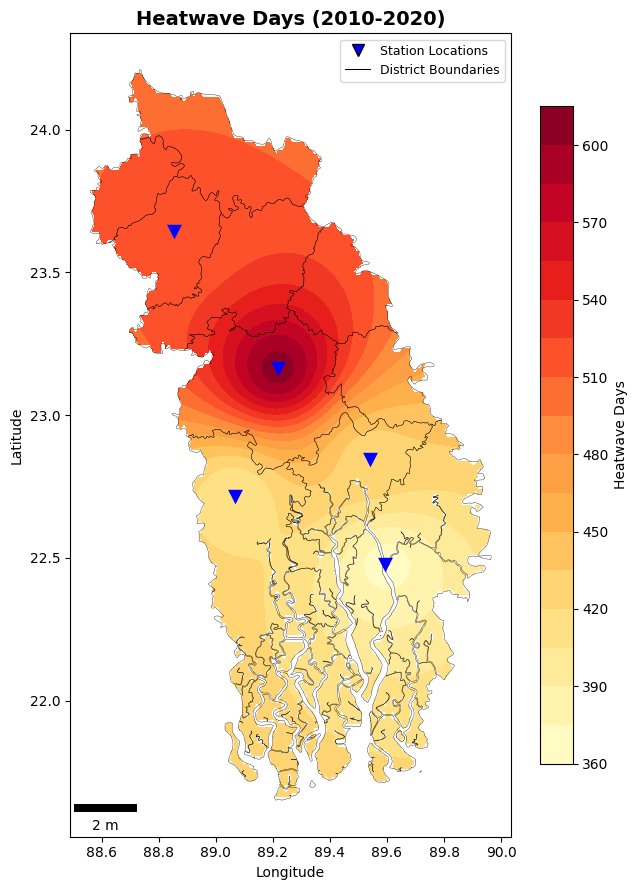

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from google.colab import drive
drive.mount('/content/drive')

# Import Line2D for legend proxy
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm # Added for font management
from matplotlib_scalebar.scalebar import ScaleBar # Import ScaleBar
import pandas as pd # Import pandas for data handling
from io import StringIO # Import StringIO for reading string data

def generate_idw(lons, lats, values, grid_lon, grid_lat, power=2):
    """
    Calculates the Inverse Distance Weighting (IDW) interpolation.
    """
    glon_flat = grid_lon.flatten()
    glat_flat = grid_lat.flatten()

    # Calculate distance matrix (grid points vs station points)
    dists = np.sqrt((glon_flat[:, np.newaxis] - lons)**2 + (glat_flat[:, np.newaxis] - lats)**2)

    # Prevent division by zero if a grid point perfectly matches a station
    dists = np.where(dists == 0, 1e-10, dists)

    # Apply IDW formula
    weights = 1.0 / (dists ** power)
    weighted_values = np.sum(weights * values, axis=1) / np.sum(weights, axis=1)

    return weighted_values.reshape(grid_lon.shape)

# Function to add North Arrow
def add_north_arrow(ax, xy_pos=(0.08, 0.92), size=0.06, text_color='black', arrow_color='black'):
    x, y = xy_pos
    ax.annotate('N', xy=(x, y), xytext=(0, size), textcoords=ax.transAxes, arrowprops=dict(facecolor=arrow_color, edgecolor=arrow_color, shrink=0.05),
                ha='center', va='bottom', fontsize=12, color=text_color, weight='bold', zorder=7)

# 1. Prepare the Station Data
stations = ['Chuadanga', 'Jessore', 'Khulna', 'Mongla', 'Satkhira']

# Approximate coordinates for the stations
lons = np.array([88.8556, 89.2182, 89.5403, 89.5960, 89.0706])
lats = np.array([23.6439, 23.1634, 22.8456, 22.4795, 22.7153])

# Climate Data specifically for Heatwave Days (2010-2020)
heatwave_data_str_2010_2020 = """Station Name\tHeatwave Days (2010-2020)
Chuadanga\t515
Jessore\t607
Khulna\t427
Mongla\t369
Satkhira\t406"""
df_heatwave_2010_2020 = pd.read_csv(StringIO(heatwave_data_str_2010_2020), sep='\t')
heatwave_2010_2020 = df_heatwave_2010_2020['Heatwave Days (2010-2020)'].values

# Use the specific data for the plot
heatwave_days_period = heatwave_2010_2020 # Assign the specific heatwave data here

# 2. Load Boundary and Setup Spatial Grid
# Replace this with the path to your actual shapefile (e.g., 'khulna_division.shp')
boundary_path='/content/drive/MyDrive/Colab_Notebooks/khulna_division.shx'

try:
    boundary_gdf = gpd.read_file(boundary_path)
    # Get the bounding box of the shapefile
    minx, miny, maxx, maxy = boundary_gdf.total_bounds
    # Use union_all() instead of unary_union to avoid DeprecationWarning
    study_polygon = boundary_gdf.geometry.union_all()
    print("Boundary loaded successfully. Clipping grid to study area.")

    # Apply 5% padding to the bounding box to "zoom out"
    padding_percentage = 0.05
    bbox_width = maxx - minx
    bbox_height = maxy - miny
    minx -= bbox_width * padding_percentage
    maxx += bbox_width * padding_percentage
    miny -= bbox_height * padding_percentage
    maxy += bbox_height * padding_percentage

except Exception as e:
    print(f"Could not load boundary file ({e}). Falling back to point bounding box.")
    # Fallback padding if no shapefile is found
    pad = 5.0
    minx, maxx = lons.min() - pad, lons.max() + pad
    miny, maxy = lats.min() - pad, lats.max() + pad
    study_polygon = None

# Create the coordinate grid
grid_lon, grid_lat = np.meshgrid(
    np.linspace(minx, maxx, 200),
    np.linspace(miny, maxy, 200)
)

# 3. Calculate IDW Interpolation for Heatwave Days
idw_heat_period = generate_idw(lons, lats, heatwave_days_period, grid_lon, grid_lat, power=2)

# Apply the spatial mask if a boundary was loaded
if study_polygon is not None:
    # Check if each point in the grid is inside the polygon
    print("Masking values outside the boundary. This might take a few seconds...")
    mask = np.array([
        study_polygon.contains(Point(x, y))
        for x, y in zip(grid_lon.flatten(), grid_lat.flatten())
    ]).reshape(grid_lon.shape)

    # Set values outside the boundary to NaN so they won't plot
    idw_heat_period = np.where(mask, idw_heat_period, np.nan)

# Before plotting, configure matplotlib to use an emoji font if available
found_emoji_font = False
for font in fm.fontManager.ttflist:
    if 'Noto Color Emoji' in font.name:
        plt.rcParams['font.sans-serif'] = ['Noto Color Emoji', 'DejaVu Sans', 'sans-serif'] # Prioritize Noto, then fallback
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break
    elif 'Segoe UI Emoji' in font.name: # For Windows environments
        plt.rcParams['font.sans-serif'] = ['Segoe UI Emoji', 'DejaVu Sans', 'sans-serif']
        plt.rcParams['font.family'] = 'sans-serif'
        found_emoji_font = True
        break

if not found_emoji_font:
    plt.rcParams['font.family'] = 'sans-serif'
    print("Warning: No specific emoji font found. Pin emoji might not display correctly.")

# 4. Plot the Map for Heatwave Days (2010-2020)
fig, ax = plt.subplots(1, 1, figsize=(8, 9)) # Single subplot

contour = ax.contourf(grid_lon, grid_lat, idw_heat_period, levels=20, cmap='YlOrRd') # Updated colormap for heatwave

# Add station pins using text (unicode character for pin) with red color
for lon, lat in zip(lons, lats):
    ax.text(lon, lat, '\u25BC', fontsize=14, ha='center', va='center', zorder=8, color='Blue')

# Plot boundary outline
if study_polygon is not None:
    boundary_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25, zorder=6)

ax.set_title('Heatwave Days (2010-2020)', fontsize=14, weight='bold') # Updated title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude', rotation='vertical')
fig.colorbar(contour, ax=ax, label='Heatwave Days', fraction=0.046, pad=0.04) # Updated colorbar label

# Set aspect ratio for accurate scale bar
ax.set_aspect('equal', adjustable='box')

# Calculate dx for ScaleBar
mean_lat = (miny + maxy) / 2
meters_per_deg_lat = 110574 # Approx. meters per degree latitude
scalebar_dx = 1000 / meters_per_deg_lat # Adjusted for kilometers

# Add North Arrow and Scale Bar
add_north_arrow(ax)
scalebar = ScaleBar(scalebar_dx, 'km', length_fraction=0.25, height_fraction=0.01,
                     location='lower left', frameon=False, font_properties={'size': 10})
ax.add_artist(scalebar)

# Add Legend
station_proxy = Line2D([0], [0], marker='v', markersize=8, markeredgecolor='black', linestyle='None', label='Station Locations',
                       color='Blue')
district_boundary_proxy = Line2D([0], [0], linestyle='-', color='black', linewidth=0.75, label='District Boundaries')
ax.legend(handles=[station_proxy, district_boundary_proxy], loc='upper right', frameon=True, fontsize=9)


# Clean up layout and display/save
plt.tight_layout()
plt.savefig('heatwave_2010_2020_map.png', dpi=300, bbox_inches='tight') # Updated filename
plt.show()
# Download trigger for Google Colab
try:
    from google.colab import files
    files.download('heatwave_2010_2020_map.png')
except ImportError:
    pass